In [6]:
library(miic)
library(data.table)
library(igraph)

In [9]:
#Cargamos los datos
setwd("/home/vant/Documentos/Master/TFM")
datos <- fread("challenge/syntheticEHR/miic_graph/input/matriz_comorbilidad_clean.csv", data.table = FALSE)
head(datos)

,Edad_Debut_Diabetes,Sexo_Hombre,Acquired heart diseases,Age-related macular degeneration,Alcohol dependence,Anxiety disorder,Arthrosis/spondylosis,Asthma,Atrial fibrillation,Behavioural and emotional disorders with onset usually occurring in childhood and adolescence,⋯,Regional enteritis and ulcerative colitis,Retinopathy,Rheumatoid arthritis and related diseases,Schizophrenia,Sequelae of cerebrovascular diseases,Stomach cancer,Thyroid cancer,Tobacco dependence,Urinary lithiasis,Uterine cancer
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,70,0,0,0,0,1,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,65,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,61,1,0,0,1,0,1,0,0,0,⋯,0,0,0,0,1,0,0,0,0,0
4,72,1,0,0,0,0,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,68,1,0,1,0,0,1,0,0,0,⋯,0,1,0,0,0,0,0,1,0,0
6,48,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [10]:
# 1. Quitar SIEMPRE las variables sin varianza (ej. Diabetes = 100%)
cols_binarias <- setdiff(colnames(datos), "Edad_Debut_Diabetes")
prevalencias <- sapply(datos[cols_binarias], mean, na.rm = TRUE)

vars_constantes <- names(prevalencias[prevalencias == 0 | prevalencias == 1])
cat("Variables constantes eliminadas:", vars_constantes, "\n")

Variables constantes eliminadas: Diabetes 


In [11]:
# 2. Aplicar umbral de prevalencia mínima (1%)
umbral <- 0.01
vars_a_mantener <- names(prevalencias[prevalencias >= umbral & prevalencias < 1])

cat("Variables originales:", length(cols_binarias), "\n")
cat("Variables mantenidas:", length(vars_a_mantener), "\n")
cat("Variables eliminadas por baja prevalencia:", length(cols_binarias) - length(vars_a_mantener) - length(vars_constantes), "\n")

Variables originales: 77 
Variables mantenidas: 32 
Variables eliminadas por baja prevalencia: 44 


In [12]:
# 3. Construir el dataset filtrado
datos_filtrado <- datos[, c("Edad_Debut_Diabetes", vars_a_mantener)]
dim(datos_filtrado)

fwrite(datos_filtrado, "challenge/syntheticEHR/miic_graph/output/matriz_comorbilidad_filtrada.csv")

[1] 899883     33

In [13]:
# Guarda también qué se quitó, para documentar la decisión en tu TFM
eliminadas <- setdiff(cols_binarias, vars_a_mantener)
write.csv(data.frame(variable = eliminadas, prevalencia = prevalencias[eliminadas]),
          "challenge/syntheticEHR/miic_graph/output/variables_eliminadas.csv", row.names = FALSE)

vars_interes <- c("Chronic kidney disease", "Ischemic heart disease", "Retinopathy")

In [18]:
#Resultado final
state_order <- data.frame(
  var_names = colnames(datos_filtrado),
  var_type = ifelse(colnames(datos_filtrado) == "Edad_Debut_Diabetes", 1, 0)
)

resultado_final <- miic(
  input_data = datos_filtrado[sample(nrow(datos_filtrado), 20000), ],
  state_order = state_order,
  n_threads = parallel::detectCores() - 1,
  n_shuffles = 100,        # ahora sí calcula confianza real
  conf_threshold = 0.01    # filtra aristas poco confiables
)

nrow(resultado_final$summary)  # debería ser bastante menor a 399
plot(resultado_final, show_labels = TRUE, label_size = 3, edge_width = 0.5, node_size = 5)

Search all pairs for unconditional independence relations...
Search for candidate separating nodes...
Search for conditional independence relations...


ERROR: Error in miic(input_data = datos_filtrado[sample(nrow(datos_filtrado), : Interupted by user


In [ ]:
#Guargamos el grafo en formato igraph para poder manipularlo y visualizarlo mejor en un png
g <- export(resultado_final, "igraph")

png("challenge/syntheticEHR/miic_graph/output/miic_grafo.png", width = 3200, height = 2400, res = 300)

plot(g,
     vertex.size = 8,
     vertex.label.cex = 0.7,
     vertex.color = "lightblue",
     edge.arrow.size = 0.4,
     layout = layout_with_fr(g))

dev.off()

png 
  2

- Vamos a analizar ahora nuestras tres enfermedades de interes

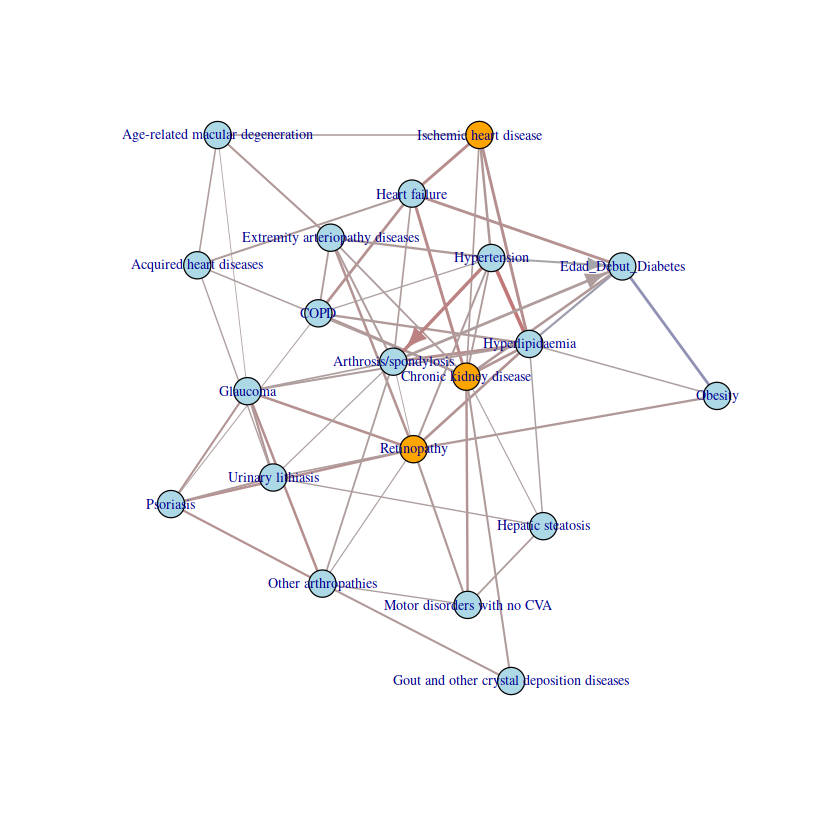

In [26]:
#Vemos el plot con las tres enfermedades resaltadas
todos_relevantes <- unique(c(vars_interes, unlist(vecinos)))
subg <- induced_subgraph(g, todos_relevantes)

# Colorea las 3 de interés distinto al resto
colores <- ifelse(V(subg)$name %in% vars_interes, "orange", "lightblue")

plot(subg, vertex.color = colores, vertex.size = 10, vertex.label.cex = 0.7,
     layout = layout_with_fr(subg))

In [ ]:
#Ver todas las relaciones de las variables de interés con las demás variables
for (v in vars_interes) {
  cat("\n===", v, "===\n")
  rel <- resultado_final$summary[
    resultado_final$summary$x == v | resultado_final$summary$y == v,
  ]
  print(rel)
}


=== Chronic kidney disease ===
                                   x                                          y
5             Chronic kidney disease                              Heart failure
17            Chronic kidney disease                            Hyperlipidaemia
24            Chronic kidney disease                        Edad_Debut_Diabetes
30            Chronic kidney disease                Motor disorders with no CVA
33            Chronic kidney disease                                       COPD
59            Chronic kidney disease Gout and other crystal deposition diseases
68            Chronic kidney disease                               Hypertension
72            Chronic kidney disease            Extremity arteriopathy diseases
88            Chronic kidney disease                     Ischemic heart disease
97           Acquired heart diseases                     Chronic kidney disease
113           Chronic kidney disease                          Hepatic steatosis
134     

In [22]:
#Ver las relaciones comunes entre las variables de interés
vecinos <- lapply(vars_interes, function(v) {
  neighbors(g, v, mode = "all")$name
})
names(vecinos) <- vars_interes

# Comunes a las 3
print(x = "Relaciones comunes entre Chronic kidney disease, Ischemic heart disease y Retinopathy:")
Reduce(intersect, vecinos)

# Comunes entre pares
print("Relaciones comunes entre Chronic kidney disease e Ischemic heart disease:")
intersect(vecinos[["Chronic kidney disease"]], vecinos[["Ischemic heart disease"]])
print("Relaciones comunes entre Chronic kidney disease y Retinopathy:")
intersect(vecinos[["Chronic kidney disease"]], vecinos[["Retinopathy"]])
print("Relaciones comunes entre Ischemic heart disease y Retinopathy:")
intersect(vecinos[["Ischemic heart disease"]], vecinos[["Retinopathy"]])

# Exclusivos de cada una (no compartidos con las otras dos)
print("Relaciones exclusivas de Chronic kidney disease:")
setdiff(vecinos[["Chronic kidney disease"]], union(vecinos[["Ischemic heart disease"]], vecinos[["Retinopathy"]]))

[1] "Relaciones comunes entre Chronic kidney disease, Ischemic heart disease y Retinopathy:"


[1] "Hyperlipidaemia" "Hypertension"

[1] "Relaciones comunes entre Chronic kidney disease e Ischemic heart disease:"


[1] "Heart failure"   "Hyperlipidaemia" "Hypertension"

[1] "Relaciones comunes entre Chronic kidney disease y Retinopathy:"


[1] "Extremity arteriopathy diseases" "Hyperlipidaemia"                
[3] "Hypertension"                    "Motor disorders with no CVA"

[1] "Relaciones comunes entre Ischemic heart disease y Retinopathy:"


[1] "Hyperlipidaemia" "Hypertension"

[1] "Relaciones exclusivas de Chronic kidney disease:"


[1] "Edad_Debut_Diabetes"                       
[2] "Acquired heart diseases"                   
[3] "COPD"                                      
[4] "Gout and other crystal deposition diseases"
[5] "Hepatic steatosis"                         
[6] "Ischemic heart disease"

also installing the dependencies ‘formatR’, ‘lambda.r’, ‘futile.options’, ‘futile.logger’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: grid

Loading required package: futile.logger



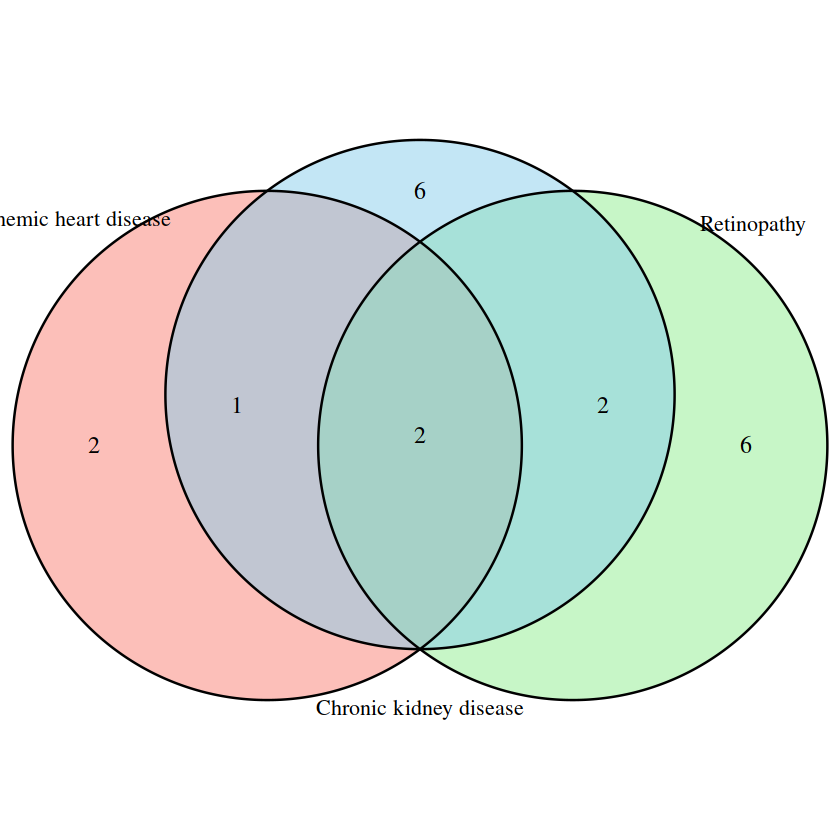

In [ ]:
#Plotear las relaciones comunes y exclusivas con un diagrama de Venn
if (!requireNamespace("VennDiagram", quietly = TRUE)) install.packages("VennDiagram")
library(VennDiagram)

venn.plot <- venn.diagram(
  x = vecinos,
  filename = NULL,
  fill = c("skyblue", "salmon", "lightgreen"),
  alpha = 0.5,
  cex = 1.2,
  cat.cex = 1.1
)
grid::grid.newpage()
grid::grid.draw(venn.plot)

'Hyperlipidaemia''Hypertension' las dos que tienen las tres enfermedades de interes